In [ ]:
""" This takes in HDFINJFIND output files and produces a plot of the fraction
of injections found as a function of chirp mass.
"""

In [ ]:
import matplotlib.pyplot as plt
import h5py
import numpy as np
from matplotlib.ticker import FormatStrFormatter

In [2]:
plt.style.use("paper.mplstyle")

In [3]:
Original_HV = "../Files/HDFINJFIND_HV_original.hdf"
Modified_HV = "../Files/HDFINJFIND_HV_modified.hdf"
Flow_HV = "../Files/HDFINJFIND_HV_flow.hdf"
Original_HL = "../Files/HDFINJFIND_LH_original.hdf"
Modified_HL = "../Files/HDFINJFIND_LH_modified.hdf"
Flow_HL = "../Files/HDFINJFIND_LH_flow.hdf"
Original_LV = "../Files/HDFINJFIND_LV_original.hdf"
Modified_LV = "../Files/HDFINJFIND_LV_modified.hdf"
Flow_LV = "../Files/HDFINJFIND_LV_flow.hdf"
Original_2DET = "../Files/HDFINJFIND_2DET_exc_sngls_original.hdf"
Modified_2DET = "../Files/HDFINJFIND_2DET_exc_sngls_modified.hdf"
Flow_2DET = "../Files/HDFINJFIND_2DET_exc_sngls_flow.hdf"
Files = [Original_2DET, Modified_2DET, Flow_2DET, Original_HL, Modified_HL, Flow_HL,Original_HV, Modified_HV, Flow_HV,Original_LV, Modified_LV, Flow_LV]


In [4]:
def chirp_mass(m1, m2):
    return (m1 * m2)**(3.0/5.0) / (m1 + m2)**(1.0/5.0)

In [5]:
def load_injection_data(h5, ifar_thresh):
    m1 = h5["injections/mass1"][:]
    m2 = h5["injections/mass2"][:]
    mc = chirp_mass(m1, m2)

    inj_idx = h5["found/injection_index"][:]
    ifar = h5["found/ifar_exc"][:]

    found_mask = ifar >= ifar_thresh
    inj_idx_found = inj_idx[found_mask]

    mc_found = mc[inj_idx_found]

    return mc, mc_found

In [6]:
chirp_bins = [
        (0.8, 2.5),
        (2.5, 20.0),
        (20.0, 50.0),
        (50.0, 1000.0),
    ]
    
bin_labels = [f"{lo}-{hi}" for lo, hi in chirp_bins]

In [7]:
all_totals = []
all_found = []
all_frac = []

for fpath in Files:
    with h5py.File(fpath, "r") as h5:
        mc_total, mc_found = load_injection_data(h5, 0.5)

    totals = []
    found = []
    frac = []

    for lo, hi in chirp_bins:
        t = np.sum((mc_total >= lo) & (mc_total < hi))
        f = np.sum((mc_found >= lo) & (mc_found < hi))
        totals.append(t)
        found.append(f)
        print(np.sum(found))
        frac.append(f / t if t > 0 else np.nan)

    all_totals.append(totals)
    all_found.append(found)
    all_frac.append(frac)

241
2184
9912
20104
242
2195
9984
20338
240
2194
9968
20317
229
2093
9375
19129
230
2093
9412
19266
230
2098
9407
19221
19
239
1385
2757
20
246
1454
2935
20
250
1457
2941
20
214
1385
2709
21
226
1466
2941
21
228
1464
2928


In [8]:
x=np.arange(len(chirp_bins))

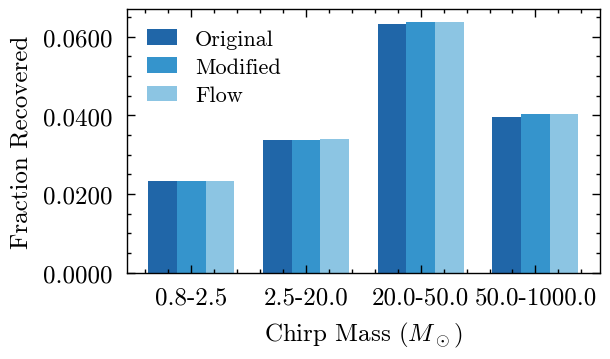

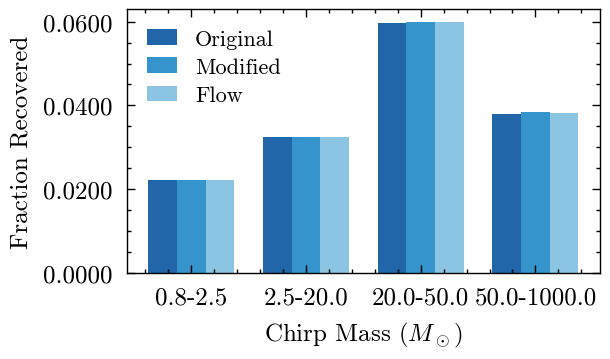

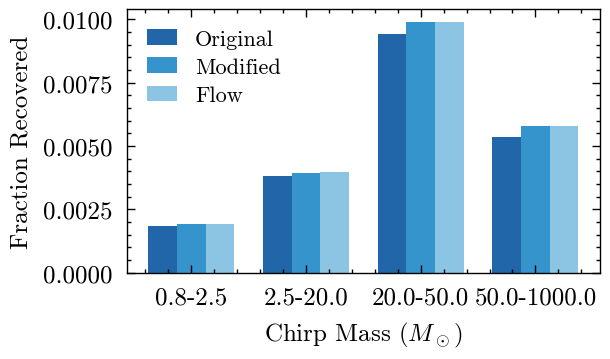

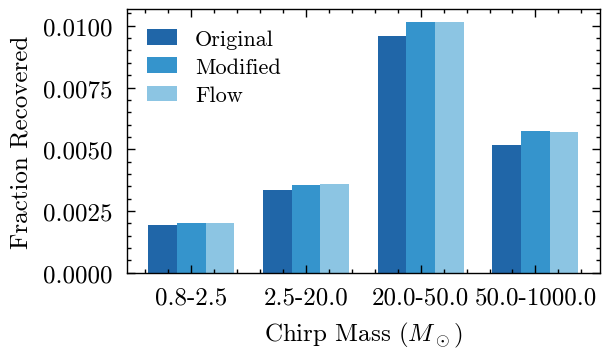

In [9]:


x = np.arange(len(chirp_bins))
width = 0.25

colors = {
    "Original": "#2066a8",
    "Modified": "#3594cc",
    "Flow":     "#8cc5e3",
}

for i in range(4):
    base = 3 * i

    fig, ax = plt.subplots()

    ax.bar(x - width, all_frac[base + 0], width,
           label="Original", color=colors["Original"])
    ax.bar(x,         all_frac[base + 1], width,
           label="Modified", color=colors["Modified"])
    ax.bar(x + width, all_frac[base + 2], width,
           label="Flow", color=colors["Flow"])

    ax.set_xlabel(r"Chirp Mass ($M_\odot$)")
    ax.set_ylabel("Fraction Recovered")
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels)

    ax.legend()
    plt.tight_layout()

    labels = ["2det_exc_sngls", "LH", "HV", "LV"]

    plt.savefig(f"../Plots/2DET_summary_{labels[i]}.png")
    plt.show()

In [12]:
Original_HLV = "../Files/HDFINJFIND_HLV_original.hdf"
Flow_HLV = "../Files/HDFINJFIND_HLV_flow.hdf"
Original_3det = "../Files/HDFINJFIND_3DET_exc_sngls_original.hdf"
Flow_3det = "../Files/HDFINJFIND_3DET_exc_sngls_flow.hdf"
Files2 = [Original_HLV, Flow_HLV, Original_3det, Flow_3det]

In [13]:
all_totals = []
all_found = []
all_frac = []

for fpath in Files2:
    with h5py.File(fpath, "r") as h5:
        mc_total, mc_found = load_injection_data(h5, 0.5)

    totals = []
    found = []
    frac = []

    for lo, hi in chirp_bins:
        t = np.sum((mc_total >= lo) & (mc_total < hi))
        f = np.sum((mc_found >= lo) & (mc_found < hi))
        totals.append(t)
        found.append(f)
        print(np.sum(found))
        frac.append(f / t if t > 0 else np.nan)

    all_totals.append(totals)
    all_found.append(found)
    all_frac.append(frac)

20
224
1489
3340
21
229
1526
3450
240
2186
9924
20177
241
2181
9940
20284


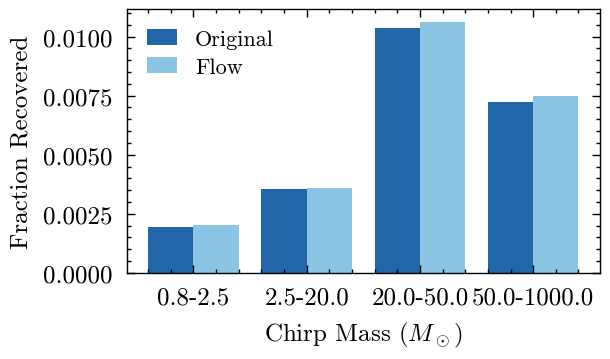

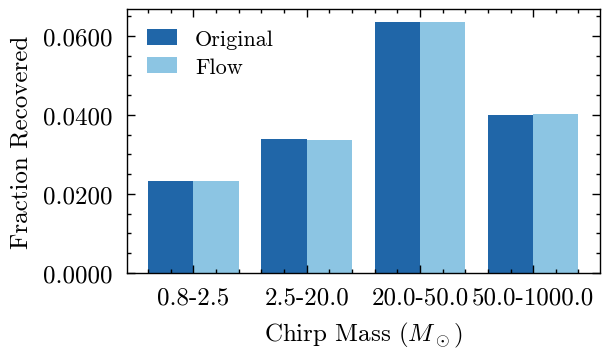

In [14]:
x = np.arange(len(chirp_bins))
width = 0.4

colors = {
    "Original": "#2066a8",
    "Flow":     "#8cc5e3",
}

for i in range(2):
    base = 2 * i

    fig, ax = plt.subplots()

    ax.bar(x - width/2, all_frac[base + 0], width,
           label="Original", color=colors["Original"])
    ax.bar(x + width/2, all_frac[base + 1], width,
           label="Flow", color=colors["Flow"])

    ax.set_xlabel(r"Chirp Mass ($M_\odot$)")
    ax.set_ylabel("Fraction Recovered")
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels)

    ax.legend()
    plt.tight_layout()

    labels = ["HLV", "3det_exc_sngls"]

    plt.savefig(f"../Plots/3DET_summary_{labels[i]}.png")
    plt.show()